## **Regressão Logística**

Dado um conjunto de observações

$$
\mathcal{D} = \{(\mathbf{x}_i, y_i)\}_{i=1}^N
$$

onde

$$
\mathbf{x}_i =
\begin{bmatrix}
  x_{i1} \\ x_{i2} \\ \vdots \\ x_{iD}
  \end{bmatrix} \in \mathbb{R}^{D} \quad
  y_i \in \{0, 1\}
$$

vamos construir a matriz $X$ do seguinte modo, seja $\tilde{x}$ o valor de x com intercepto:

$$
\tilde{\mathbf{x}}_i =
\begin{bmatrix}
1 \\ x_{i1} \\ \vdots \\ x_{iD}
\end{bmatrix} \in \mathbb{R}^{D+1},
\quad
\boldsymbol{\beta} =
\begin{bmatrix}
\beta_0 \\ \beta_1 \\ \ldots \\ \beta_D
\end{bmatrix} \in \mathbb{R}^{D+1}
$$

então $X$ é dada por:

$$
  \mathbf{X} =
  \begin{bmatrix}
  \tilde{\mathbf{x}}_1^{\top} \\
  \tilde{\mathbf{x}}_2^{\top} \\
  \vdots  \\
  \tilde{\mathbf{x}}_N^{\top}
  \end{bmatrix} =
  \begin{bmatrix}
  1 & x_{11} & x_{12} & \cdots & x_{1D} \\
  1 & x_{21} & x_{22} & \cdots & x_{2D} \\
  \vdots & \vdots & \vdots & \ddots & \vdots \\
  1 & x_{N1} & x_{N2} & \cdots & x_{ND}
  \end{bmatrix} \in \mathbb{R}^{N \times (D + 1)}
$$

Sabemos que $y_{i} \sim \text{Bernoulli}(p_{i})$ onde $p_i$ é dada por:

$$
p_i = P(y_i = 1 \mid \mathbf{x}_i;\, \boldsymbol{\beta}) = \sigma\left(\tilde{\mathbf{x}}_i^{\top} \boldsymbol{\beta}\right)$$

onde

$$
 \sigma\left(\tilde{\mathbf{x}}_i^{\top} \boldsymbol{\beta}\right) = \frac{1}{1 + e^{-(\tilde{\mathbf{x}}_i^{\top}\boldsymbol{\beta})}}
$$

Assumindo a independência de $y_i$ em relação a $X$, vamos ainda definir a função de verossimilhança como:

$$
\mathcal{L}(\boldsymbol{\beta}) = \prod_{i=1}^{N} p_i^{y_i}(1 - p_i)^{(1 - y_i)}
$$

Substituindo $p_i$ por $ \sigma\left(\tilde{\mathbf{x}}_i^{\top} \boldsymbol{\beta}\right)$ temos que:

$$
\mathcal{L}(\boldsymbol{\beta}) = \prod_{i=1}^{N} [\sigma\left(\tilde{\mathbf{x}}_i^{\top} \boldsymbol{\beta}\right)]^{y_i}[1 - \sigma\left(\tilde{\mathbf{x}}_i^{\top} \boldsymbol{\beta}\right)]^{1 - y_i}
$$

Fazendo $\ell(\boldsymbol{\beta}) = \log \mathcal{L}(\boldsymbol{\beta})$, segue que

$$
\ell(\boldsymbol{\beta}) = \sum_{i=1}^{N} \left[ y_i \log \sigma\!\left(\tilde{\mathbf{x}}_i^{\top}\boldsymbol{\beta}\right) + (1 - y_i)\log\!\left(1 - \sigma\!\left(\tilde{\mathbf{x}}_i^{\top}\boldsymbol{\beta}\right)\right) \right]
$$

Essa é a chamada **função log-verossimilhança**.

Dada a função $\ell(\boldsymbol{\beta})$, podemos seguir com duas abordagens:

*   Método de Newton
*   Método do Gradiente Descendente

### **Método de Newton**

Nessa técnica, o objetivo é maximizar a função log-verossimilhança. Nesse método, a iteração é dada por:


$$
\boldsymbol{\beta}^{(t+1)} = \boldsymbol{\beta}^{(t)} - \mathbf{H}^{-1}\left(\boldsymbol{\beta}^{(t)}\right)\, \nabla \ell\left(\boldsymbol{\beta}^{(t)}\right)$$

onde $\nabla \ell(\boldsymbol{\beta})$ é o gradiente e $\mathbf{H}$ é a matriz Hessiana.

Calculando $\nabla \ell(\boldsymbol{\beta})$ temos:

$$
\nabla \ell(\boldsymbol{\beta}) = X^{\top}(\mathbf{y} - \mathbf{p})
$$

Sendo a matriz Hessiana dada por:

$$
\mathbf{H} = -\mathbf{X}^{\top}\mathbf{W}\mathbf{X}
$$

onde:

$$
\mathbf{W} = \operatorname{diag}(p_i(1 - p_i))
$$

Substituindo na fórmula de iteração, temos que:

$$
\boldsymbol{\beta}^{(t+1)} = \boldsymbol{\beta}^{(t)} + \left(\mathbf{X}^{\top}\mathbf{W}\mathbf{X}\right)^{-1} \mathbf{X}^{\top}(\mathbf{y} - \mathbf{p})
$$


### **Método do Gradiente Descendente**

Em ML geralmente **minimizamos** a função chamada de **Entropia Cruzada**, também conhecida por log-verossimilhança negativa:


$$
J(\boldsymbol{\beta}) = -\dfrac{1}{N}\ell(\boldsymbol{\beta})
$$

onde $\ell(\boldsymbol{\beta})$ é a função de log-verossimilhança.

Substuindo, temos que:

$$
J(\boldsymbol{\beta}) = -\frac{1}{N} \sum_{i=1}^{N} \left[ y_i \log \sigma\!\left(\tilde{\mathbf{x}}_i^{\top}\boldsymbol{\beta}\right) + (1 - y_i)\log\left(1 - \sigma\left(\tilde{\mathbf{x}}_i^{\top}\boldsymbol{\beta}\right)\right) \right]
$$

Como dito, queremos no método do GD deseja-se minimizar $J(\boldsymbol{\beta})$. Para isso, usa-se a seguinte iteração:

$$
\boldsymbol{\beta}^{(t+1)} = \boldsymbol{\beta}^{(t)} - \eta \, \nabla J\left(\boldsymbol{\beta}^{(t)}\right)
$$

Dado que $\nabla J(\boldsymbol{\beta})$ é dado por:

$$
\nabla J(\boldsymbol{\beta}) = \frac{1}{N}\, \mathbf{X}^{\top}(\mathbf{p} - \mathbf{y})$$

temos que:

$$
\boldsymbol{\beta}^{(t+1)} = \boldsymbol{\beta}^{(t)} - \frac{\eta}{N}\, X^{\top}\!\left(\mathbf{p}^{(t)} - \mathbf{y}\right)
$$

### **Aplicação Básica de Regressão Logística usando o Método de Newton**

Vamos utilizar a **Regressão Logística** para uma tarefa de **classificação**, em um dataset local contendo horas de sono e de estudo de estudantes, juntamente com um rótulo indicando se foram aprovados ou não.

#### **Definindo as funções que irão calcular a sigmoide $\sigma(z)$, o gradiente $\nabla \ell(\boldsymbol{\beta})$ e a matriz Hessiana $\mathbf{H}$:**

In [ ]:
import numpy as np

data = np.loadtxt(
    "data.csv",
    delimiter=",",
    skiprows=1
)

X1 = data[:, 0]
X2 = data[:, 1]
Y  = data[:, 2]

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def gradient(X, y, beta):
    p = sigmoid(X @ beta)
    return X.T @ (y - p)

def hessian(X, beta):
    p = sigmoid(X @ beta)
    W = np.diag(p * (1 - p))
    return - X.T @ W @ X


#### **Implementando a Regressão Logística**

In [ ]:
def logistic_regression_newton(X, y, max_iter=100, tol=1e-6):
    n, d = X.shape
    beta = np.zeros(d)

    for i in range(max_iter):
        grad = gradient(X, y, beta)
        H = hessian(X, beta)

        delta = np.linalg.solve(H, grad)
        beta_new = beta - delta

        if np.linalg.norm(beta_new - beta) < tol:
            beta = beta_new
            break

        beta = beta_new

    return beta

#### **Contrução da matriz $X$ e cálculo da regressão:**

In [ ]:
X = np.column_stack((np.ones(len(X1)), X1, X2))

beta = logistic_regression_newton(X, Y)

print(beta)

[-16.1602695    1.74538164   1.48650834]


#### **Vizualização dos pontos no plano**

Nesse exemplo, as variáveis independentes são horas estudadas e tempo de sono, que determinam se o aluno foi aprovado ou reprovado.

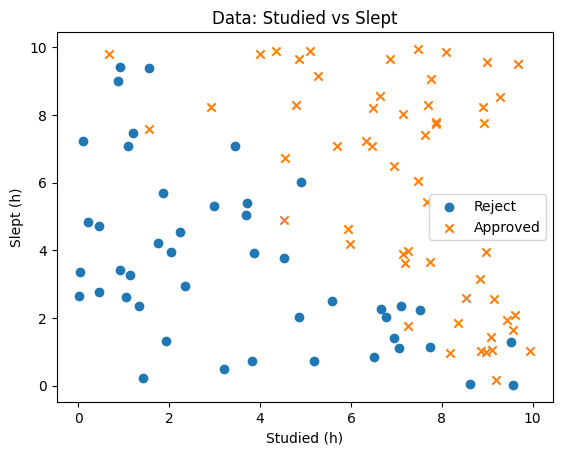

In [ ]:
import matplotlib.pyplot as plt

plt.figure()

plt.scatter(X1[Y==0], X2[Y==0], marker='o', label='Reject')
plt.scatter(X1[Y==1], X2[Y==1], marker='x', label='Approved')

plt.xlabel('Studied (h)')
plt.ylabel('Slept (h)')
plt.legend()
plt.title('Data: Studied vs Slept')
plt.show()


#### **Uso do vetor $\boldsymbol{\beta}$ para determinar fronteira de decisão**

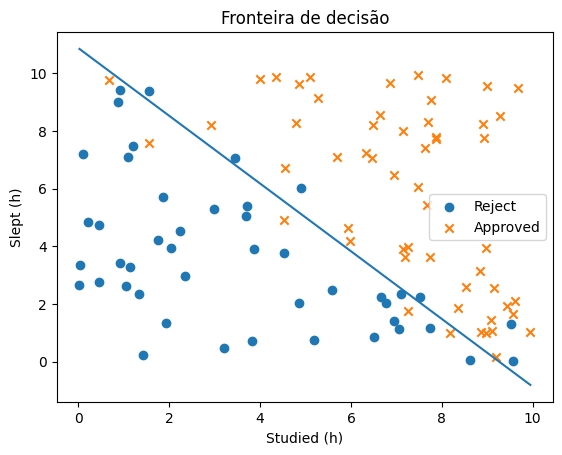

In [ ]:
x1_vals = np.linspace(X1.min(), X1.max(), 100)
x2_vals = -(beta[0] + beta[1]*x1_vals) / beta[2]

plt.figure()

plt.scatter(X1[Y==0], X2[Y==0], marker='o', label='Reject')
plt.scatter(X1[Y==1], X2[Y==1], marker='x', label='Approved')

plt.plot(x1_vals, x2_vals)
plt.xlabel('Studied (h)')
plt.ylabel('Slept (h)')
plt.legend()
plt.title('Fronteira de decisão')
plt.show()


#### **Realizando Predição de um novo aluno**

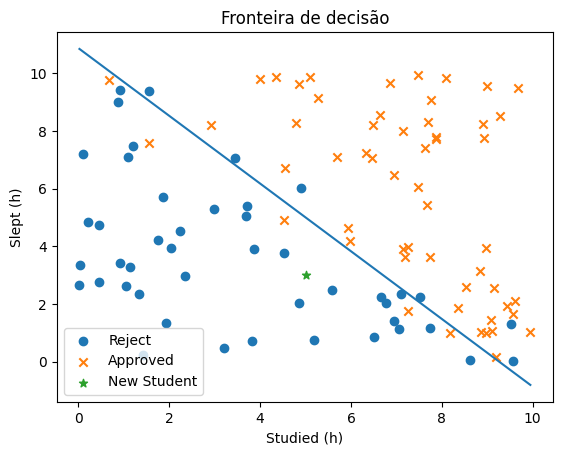

In [ ]:
slept = 3
studied = 5

plt.figure()

plt.scatter(X1[Y==0], X2[Y==0], marker='o', label='Reject')
plt.scatter(X1[Y==1], X2[Y==1], marker='x', label='Approved')
plt.scatter(studied, slept, marker='*', label='New Student')

plt.plot(x1_vals, x2_vals)
plt.xlabel('Studied (h)')
plt.ylabel('Slept (h)')
plt.legend()
plt.title('Fronteira de decisão')
plt.show()

In [ ]:
def predict(X, beta):
    probs = sigmoid(X @ beta)
    return (probs >= 0.5).astype(int), probs.round(4)

def name_class(y):
  _class = "Reject" if y == 0 else "Approved"
  return _class

x_new = np.array([1, studied, slept])

y_predict, prob = predict(x_new, beta)

print("Probabilidade de aprovação:", prob)

print("Classe prevista:", name_class(y_predict))

Probabilidade de aprovação: 0.0486
Classe prevista: Reject
